1. Laoding Library

In [1028]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [1029]:
cpi = 'CPI.csv' # Consumer price index
eci = 'ECI.csv' #  Employment cost index
csi = 'CONSUMER-SENTIMENT-INDEX.csv' # Consumer sentiment index
gpd = 'GPD-PRICE-DEFLATOR.csv' # Price deflator
ipd = 'IMPORT-PRICE-INDEX.csv' # Import price index
op = 'OIL-PRICE.csv' # WPI oil prices
pce = 'PCE.csv' # Personal consumption expenditures
ppi = 'PPI.csv' # Producer price index
wg = 'WAGE-GROWTH.csv' # Wage growth

In [1030]:
df = pd.read_csv("CPI.csv")
df

,DATE,CPIAUCSL
0,1947-01-01,21.480
1,1947-02-01,21.620
2,1947-03-01,22.000
3,1947-04-01,22.000
4,1947-05-01,21.950
...,...,...
924,2024-01-01,309.685
925,2024-02-01,311.054
926,2024-03-01,312.230
927,2024-04-01,313.207


In [1031]:
df_cpi = pd.read_csv(cpi, index_col='DATE', parse_dates=True)
df_eci = pd.read_csv(eci, index_col='DATE', parse_dates=True)
df_csi = pd.read_csv(csi)
df_gpd = pd.read_csv(ipd, index_col='DATE', parse_dates=True)
df_op = pd.read_csv(op, index_col='DATE', parse_dates=True)
df_pce = pd.read_csv(pce, index_col='DATE', parse_dates=True)
df_ppi = pd.read_csv(ppi, index_col='DATE', parse_dates=True)
df_wg = pd.read_csv(wg, index_col='DATE', parse_dates=True)

2. DATA EXPLORATION

In [1032]:
def check_outlier(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    return df[ (df[col] > Q3 + 1.5 * IQR) | (df[col] < Q1 - 1.5 * IQR)]

In [1033]:
df_cpi

,CPIAUCSL
DATE,
1947-01-01,21.480
1947-02-01,21.620
1947-03-01,22.000
1947-04-01,22.000
1947-05-01,21.950
...,...
2024-01-01,309.685
2024-02-01,311.054
2024-03-01,312.230


In [1034]:
df_cpi = df_cpi[df_cpi.index >= "2001-01-01"]
df_cpi

,CPIAUCSL
DATE,
2001-01-01,175.600
2001-02-01,176.000
2001-03-01,176.100
2001-04-01,176.400
2001-05-01,177.300
...,...
2024-01-01,309.685
2024-02-01,311.054
2024-03-01,312.230


In [1035]:
df_cpi.resample("QS").mean()

,CPIAUCSL
DATE,
2001-01-01,175.900000
2001-04-01,177.133333
2001-07-01,177.633333
2001-10-01,177.500000
2002-01-01,178.066667
...,...
2023-04-01,303.466667
2023-07-01,306.034333
2023-10-01,308.099000


In [1036]:
check_outlier(df_cpi, 'CPIAUCSL')

,CPIAUCSL
DATE,


In [1037]:
df_cpi = df_cpi.resample('QS').mean()
df_cpi

,CPIAUCSL
DATE,
2001-01-01,175.900000
2001-04-01,177.133333
2001-07-01,177.633333
2001-10-01,177.500000
2002-01-01,178.066667
...,...
2023-04-01,303.466667
2023-07-01,306.034333
2023-10-01,308.099000


In [1038]:
df_eci

,CIS1020000000000I
DATE,
2001-01-01,87.6
2001-04-01,88.4
2001-07-01,89.2
2001-10-01,90.0
2002-01-01,90.7
...,...
2023-01-01,157.1
2023-04-01,158.7
2023-07-01,160.4


In [1039]:
df_gpd

,IR
DATE,
1982-09-01,80.0
1982-10-01,.
1982-11-01,.
1982-12-01,79.9
1983-01-01,.
...,...
2024-01-01,139.4
2024-02-01,139.7
2024-03-01,140.5


In [1040]:
df_gpd.replace(".", np.nan, inplace = True)

In [1041]:
df_gpd

,IR
DATE,
1982-09-01,80.0
1982-10-01,NaN
1982-11-01,NaN
1982-12-01,79.9
1983-01-01,NaN
...,...
2024-01-01,139.4
2024-02-01,139.7
2024-03-01,140.5


In [1042]:
df_gpd.isnull().sum()

IR    50
dtype: int64

In [1043]:
df_gpd.dropna(inplace = True)

In [1044]:
df_gpd

,IR
DATE,
1982-09-01,80.0
1982-12-01,79.9
1983-03-01,77.7
1983-06-01,77.8
1983-09-01,77.6
...,...
2024-01-01,139.4
2024-02-01,139.7
2024-03-01,140.5


In [1045]:
df_gpd.dtypes

IR    object
dtype: object

In [1046]:
df_gpd['IR'] = df_gpd['IR'].astype('float64')

In [1047]:
check_outlier(df_gpd, "IR")

,IR
DATE,


In [1048]:
df_op

,POILWTIUSDM
DATE,
1990-01-01,22.604348
1990-02-01,22.202500
1990-03-01,20.440455
1990-04-01,18.526667
1990-05-01,18.443043
...,...
2024-01-01,74.003043
2024-02-01,77.363810
2024-03-01,81.405714


In [1049]:
df_op.dtypes

POILWTIUSDM    float64
dtype: object

In [1050]:
check_outlier(df_op, 'POILWTIUSDM')

,POILWTIUSDM
DATE,


In [1051]:
df_pce

,PCE
DATE,
1959-01-01,306.1
1959-02-01,309.6
1959-03-01,312.7
1959-04-01,312.2
1959-05-01,316.1
...,...
2024-01-01,19028.0
2024-02-01,19136.0
2024-03-01,19263.7


In [1052]:
df_pce.dtypes

PCE    float64
dtype: object

In [1053]:
check_outlier(df_pce, 'PCE')

,PCE
DATE,


In [1054]:
df_ppi

,PPIACO
DATE,
1913-01-01,12.100
1913-02-01,12.000
1913-03-01,12.000
1913-04-01,12.000
1913-05-01,11.900
...,...
2024-01-01,251.306
2024-02-01,254.914
2024-03-01,255.116


In [1055]:
df_ppi.dtypes

PPIACO    float64
dtype: object

In [1056]:
df_ppi = df_ppi[df_ppi.index >= "2001-01-01"]
df_ppi

,PPIACO
DATE,
2001-01-01,140.000
2001-02-01,137.400
2001-03-01,135.900
2001-04-01,136.400
2001-05-01,136.800
...,...
2024-01-01,251.306
2024-02-01,254.914
2024-03-01,255.116


In [1057]:

df_ppi = df_ppi.resample('QS').mean()
df_ppi

,PPIACO
DATE,
2001-01-01,137.766667
2001-04-01,136.233333
2001-07-01,133.366667
2001-10-01,129.400000
2002-01-01,128.900000
...,...
2023-04-01,254.812667
2023-07-01,256.816333
2023-10-01,252.638000


In [1058]:
check_outlier(df_ppi, "PPIACO")

,PPIACO
DATE,
2022-04-01,272.937333
2022-07-01,269.906000
2022-10-01,262.038333
2023-01-01,258.652667
2023-07-01,256.816333


In [1059]:

df_wg

,FRBATLWGTUMHWG83O
DATE,
1983-01-01,6.5
1983-02-01,6.1
1983-03-01,5.7
1983-04-01,5.7
1983-05-01,5.8
...,...
2023-11-01,5.1
2023-12-01,5.4
2024-01-01,4.7


In [1060]:
df_wg.dtypes
df_wg

,FRBATLWGTUMHWG83O
DATE,
1983-01-01,6.5
1983-02-01,6.1
1983-03-01,5.7
1983-04-01,5.7
1983-05-01,5.8
...,...
2023-11-01,5.1
2023-12-01,5.4
2024-01-01,4.7


In [1061]:
df_wg.replace(".", np.nan, inplace=True)
df_wg

,FRBATLWGTUMHWG83O
DATE,
1983-01-01,6.5
1983-02-01,6.1
1983-03-01,5.7
1983-04-01,5.7
1983-05-01,5.8
...,...
2023-11-01,5.1
2023-12-01,5.4
2024-01-01,4.7


In [1062]:
df_wg['FRBATLWGTUMHWG83O'] = df_wg['FRBATLWGTUMHWG83O'].astype('float64')

In [1063]:
df_wg.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 495 entries, 1983-01-01 to 2024-03-01
Data columns (total 1 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   FRBATLWGTUMHWG83O  465 non-null    float64
dtypes: float64(1)
memory usage: 7.7 KB


In [1064]:
df_wg.dtypes

FRBATLWGTUMHWG83O    float64
dtype: object

In [1065]:
df_wg = df_wg[df_wg.index >= "2001-01-01"]
df_wg

,FRBATLWGTUMHWG83O
DATE,
2001-01-01,5.3
2001-02-01,5.4
2001-03-01,5.1
2001-04-01,5.4
2001-05-01,4.7
...,...
2023-11-01,5.1
2023-12-01,5.4
2024-01-01,4.7


In [1066]:
df_wg = df_wg.resample("QS").mean()
df_wg

,FRBATLWGTUMHWG83O
DATE,
2001-01-01,5.266667
2001-04-01,5.200000
2001-07-01,5.033333
2001-10-01,4.966667
2002-01-01,4.566667
...,...
2023-01-01,6.433333
2023-04-01,5.633333
2023-07-01,5.233333


In [1067]:
check_outlier(df_wg, "FRBATLWGTUMHWG83O")


,FRBATLWGTUMHWG83O
DATE,
2022-01-01,5.966667
2022-04-01,6.733333
2022-07-01,6.366667
2022-10-01,6.100000
2023-01-01,6.433333
2023-04-01,5.633333


In [1068]:
df_csi 

,,,Table 1: The Index of Consumer Sentiment
Month,Year,Index,NaN
1,1978,83.7,NaN
2,1978,84.3,NaN
3,1978,78.8,NaN
4,1978,81.6,NaN
...,...,...,...
1,2024,79,NaN
2,2024,76.9,NaN
3,2024,79.4,NaN
4,2024,77.2,NaN


In [1069]:
df_csi = df_csi.reset_index()
df_csi

,level_0,level_1,level_2,Table 1: The Index of Consumer Sentiment
0,Month,Year,Index,NaN
1,1,1978,83.7,NaN
2,2,1978,84.3,NaN
3,3,1978,78.8,NaN
4,4,1978,81.6,NaN
...,...,...,...,...
553,1,2024,79,NaN
554,2,2024,76.9,NaN
555,3,2024,79.4,NaN
556,4,2024,77.2,NaN


In [1070]:
df_csi.rename({"level_2": "csi"}, axis = 1, inplace = True)
df_csi

,level_0,level_1,csi,Table 1: The Index of Consumer Sentiment
0,Month,Year,Index,NaN
1,1,1978,83.7,NaN
2,2,1978,84.3,NaN
3,3,1978,78.8,NaN
4,4,1978,81.6,NaN
...,...,...,...,...
553,1,2024,79,NaN
554,2,2024,76.9,NaN
555,3,2024,79.4,NaN
556,4,2024,77.2,NaN


In [1071]:
df_csi.drop(labels=0, inplace=True)
df_csi.drop('Table 1: The Index of Consumer Sentiment', axis = 1, inplace = True)

In [1072]:
df_csi

,level_0,level_1,csi
1,1,1978,83.7
2,2,1978,84.3
3,3,1978,78.8
4,4,1978,81.6
5,5,1978,82.9
...,...,...,...
553,1,2024,79
554,2,2024,76.9
555,3,2024,79.4
556,4,2024,77.2


In [1073]:
df_eci

,CIS1020000000000I
DATE,
2001-01-01,87.6
2001-04-01,88.4
2001-07-01,89.2
2001-10-01,90.0
2002-01-01,90.7
...,...
2023-01-01,157.1
2023-04-01,158.7
2023-07-01,160.4


In [1074]:
df_eci.dtypes

CIS1020000000000I    float64
dtype: object

In [1075]:
df_gpd

,IR
DATE,
1982-09-01,80.0
1982-12-01,79.9
1983-03-01,77.7
1983-06-01,77.8
1983-09-01,77.6
...,...
2024-01-01,139.4
2024-02-01,139.7
2024-03-01,140.5


In [1076]:
merge1 = df_eci.join(df_gpd)

In [1077]:
merge1 = merge1.join(df_op)

In [1078]:
merge1 = merge1.join(df_pce)

In [1079]:
merge1 = merge1.join(df_ppi)

In [1080]:
merge1 = merge1.join(df_wg)

In [1081]:
merge1 = merge1.join(df_cpi)

In [1082]:
df_csi

,level_0,level_1,csi
1,1,1978,83.7
2,2,1978,84.3
3,3,1978,78.8
4,4,1978,81.6
5,5,1978,82.9
...,...,...,...
553,1,2024,79
554,2,2024,76.9
555,3,2024,79.4
556,4,2024,77.2


In [1083]:
df_csi['DATE'] = pd.to_datetime(df_csi['level_1'] + '-' + df_csi['level_0'] + '-01')

In [1084]:
df_csi

,level_0,level_1,csi,DATE
1,1,1978,83.7,1978-01-01
2,2,1978,84.3,1978-02-01
3,3,1978,78.8,1978-03-01
4,4,1978,81.6,1978-04-01
5,5,1978,82.9,1978-05-01
...,...,...,...,...
553,1,2024,79,2024-01-01
554,2,2024,76.9,2024-02-01
555,3,2024,79.4,2024-03-01
556,4,2024,77.2,2024-04-01


In [1085]:
df_csi.drop(['level_0', 'level_1'], axis=1, inplace=True)
df_csi

,csi,DATE
1,83.7,1978-01-01
2,84.3,1978-02-01
3,78.8,1978-03-01
4,81.6,1978-04-01
5,82.9,1978-05-01
...,...,...
553,79,2024-01-01
554,76.9,2024-02-01
555,79.4,2024-03-01
556,77.2,2024-04-01


In [1086]:
df_csi

,csi,DATE
1,83.7,1978-01-01
2,84.3,1978-02-01
3,78.8,1978-03-01
4,81.6,1978-04-01
5,82.9,1978-05-01
...,...,...
553,79,2024-01-01
554,76.9,2024-02-01
555,79.4,2024-03-01
556,77.2,2024-04-01


In [1087]:
df_csi.set_index(df_csi['DATE'], inplace=True)

In [1088]:
df_csi

,csi,DATE
DATE,,
1978-01-01,83.7,1978-01-01
1978-02-01,84.3,1978-02-01
1978-03-01,78.8,1978-03-01
1978-04-01,81.6,1978-04-01
1978-05-01,82.9,1978-05-01
...,...,...
2024-01-01,79,2024-01-01
2024-02-01,76.9,2024-02-01
2024-03-01,79.4,2024-03-01


In [1089]:
df_csi.drop('DATE', axis = 1, inplace=True)

In [1090]:
df_csi

,csi
DATE,
1978-01-01,83.7
1978-02-01,84.3
1978-03-01,78.8
1978-04-01,81.6
1978-05-01,82.9
...,...
2024-01-01,79
2024-02-01,76.9
2024-03-01,79.4


In [1091]:
df = merge1.join(df_csi)

In [1092]:
df.head()

,CIS1020000000000I,IR,POILWTIUSDM,PCE,PPIACO,FRBATLWGTUMHWG83O,CPIAUCSL,csi
DATE,,,,,,,,
2001-01-01,87.6,100.5,29.482174,6987.4,137.766667,5.266667,175.900000,94.7
2001-04-01,88.4,97.8,27.453810,7004.2,136.233333,5.200000,177.133333,88.4
2001-07-01,89.2,96.1,26.435909,7082.3,133.366667,5.033333,177.633333,92.4
2001-10-01,90.0,93.7,22.210435,7212.9,129.400000,4.966667,177.500000,82.7
2002-01-01,90.7,91.6,19.607391,7184.6,128.900000,4.566667,178.066667,93


In [1093]:
df.dtypes

CIS1020000000000I    float64
IR                   float64
POILWTIUSDM          float64
PCE                  float64
PPIACO               float64
FRBATLWGTUMHWG83O    float64
CPIAUCSL             float64
csi                   object
dtype: object

In [1094]:
df["csi"] =df["csi"].astype("float64")

In [1095]:
df.dtypes

CIS1020000000000I    float64
IR                   float64
POILWTIUSDM          float64
PCE                  float64
PPIACO               float64
FRBATLWGTUMHWG83O    float64
CPIAUCSL             float64
csi                  float64
dtype: object

2. DATA CLEANING

In [1096]:
df.columns = ["eci_index", 'gpd_index', 'oil_price', 'pce_index', 'ppi_index', 'wg_index', 'cpi_index', 'csi_index']

In [1097]:
df[df.index >= '2001-01-01']

,eci_index,gpd_index,oil_price,pce_index,ppi_index,wg_index,cpi_index,csi_index
DATE,,,,,,,,
2001-01-01,87.6,100.5,29.482174,6987.4,137.766667,5.266667,175.900000,94.7
2001-04-01,88.4,97.8,27.453810,7004.2,136.233333,5.200000,177.133333,88.4
2001-07-01,89.2,96.1,26.435909,7082.3,133.366667,5.033333,177.633333,92.4
2001-10-01,90.0,93.7,22.210435,7212.9,129.400000,4.966667,177.500000,82.7
2002-01-01,90.7,91.6,19.607391,7184.6,128.900000,4.566667,178.066667,93.0
...,...,...,...,...,...,...,...,...
2023-01-01,157.1,141.3,78.251364,18229.6,258.652667,6.433333,301.203000,64.9
2023-04-01,158.7,140.3,79.126500,18363.8,254.812667,5.633333,303.466667,63.7
2023-07-01,160.4,139.4,75.766667,18595.4,256.816333,5.233333,306.034333,71.5


In [1098]:
df.head()

,eci_index,gpd_index,oil_price,pce_index,ppi_index,wg_index,cpi_index,csi_index
DATE,,,,,,,,
2001-01-01,87.6,100.5,29.482174,6987.4,137.766667,5.266667,175.900000,94.7
2001-04-01,88.4,97.8,27.453810,7004.2,136.233333,5.200000,177.133333,88.4
2001-07-01,89.2,96.1,26.435909,7082.3,133.366667,5.033333,177.633333,92.4
2001-10-01,90.0,93.7,22.210435,7212.9,129.400000,4.966667,177.500000,82.7
2002-01-01,90.7,91.6,19.607391,7184.6,128.900000,4.566667,178.066667,93.0


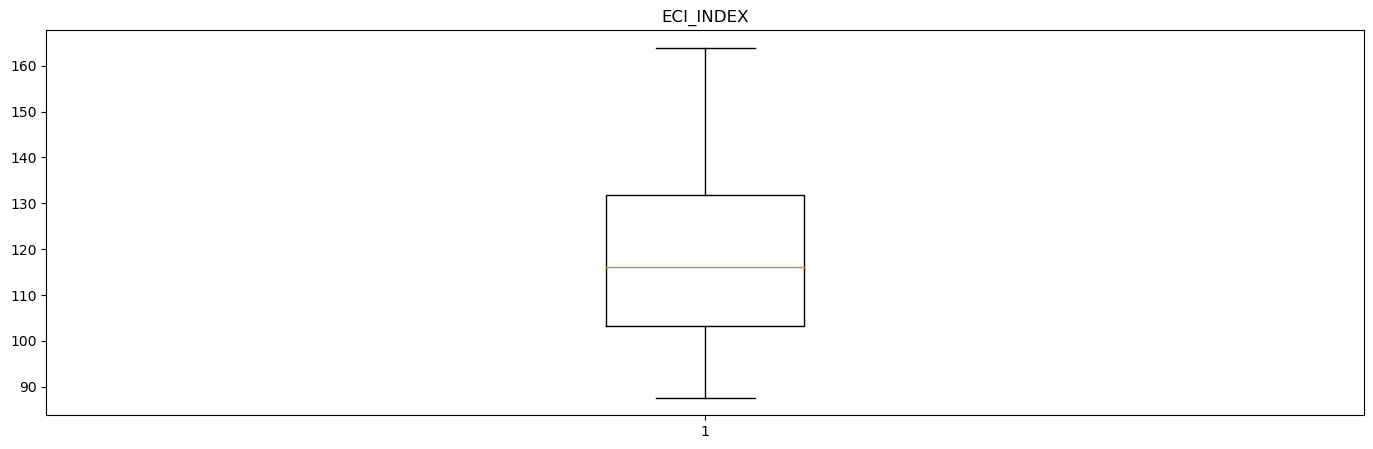

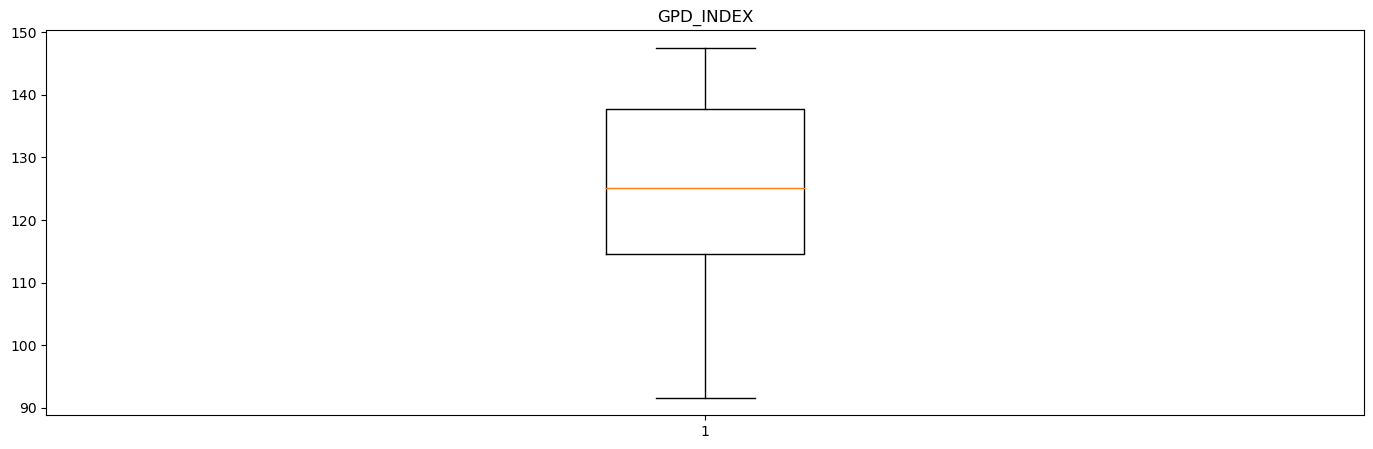

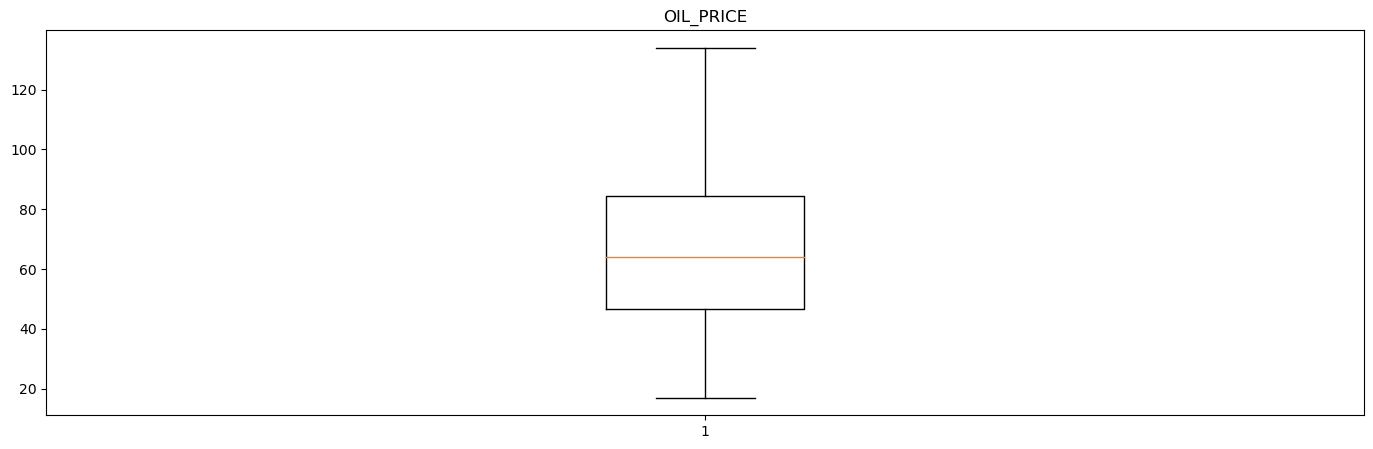

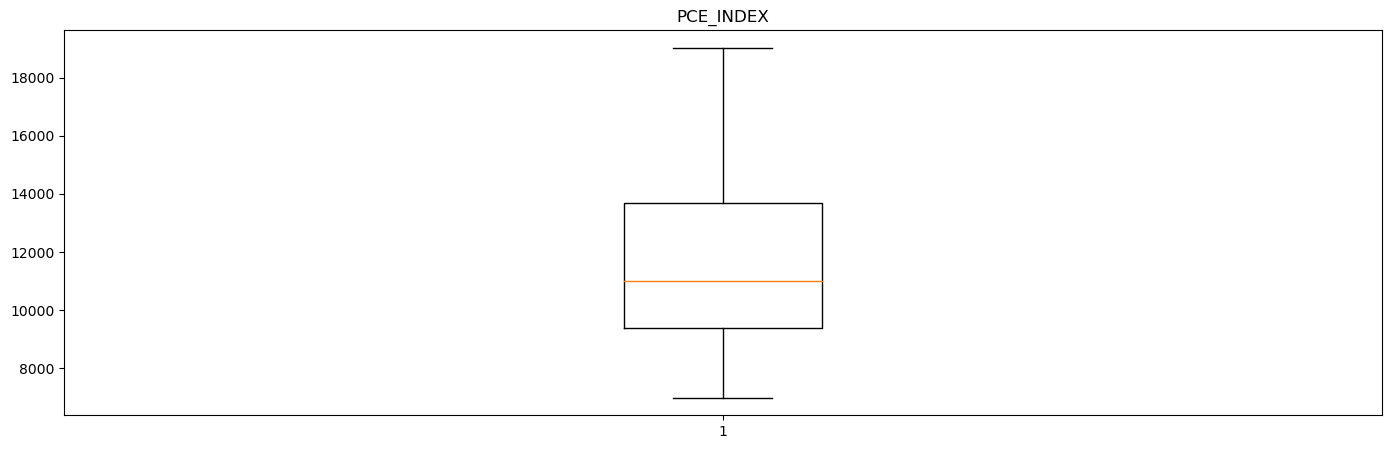

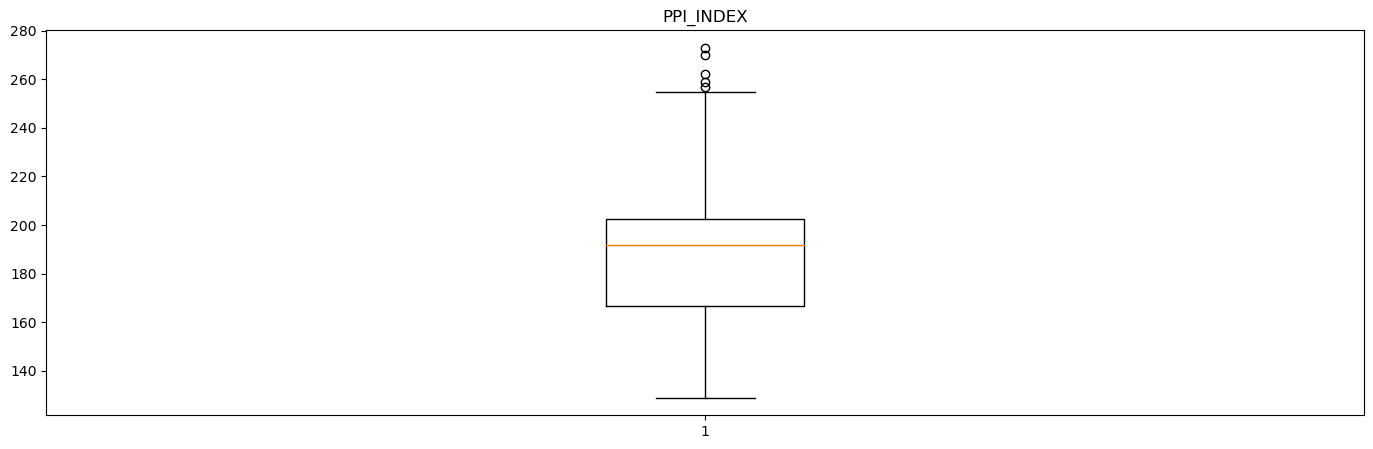

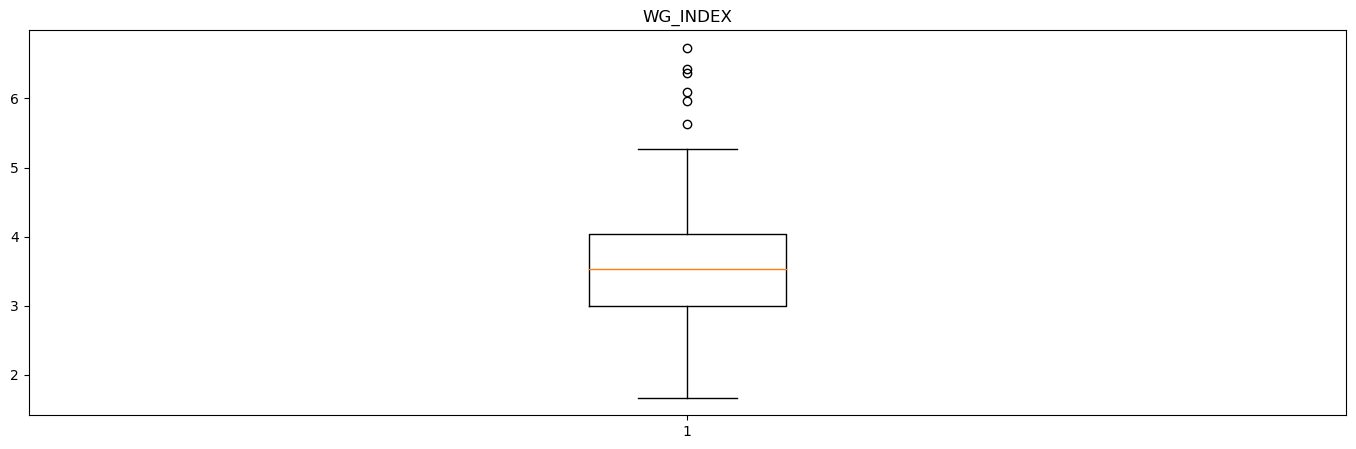

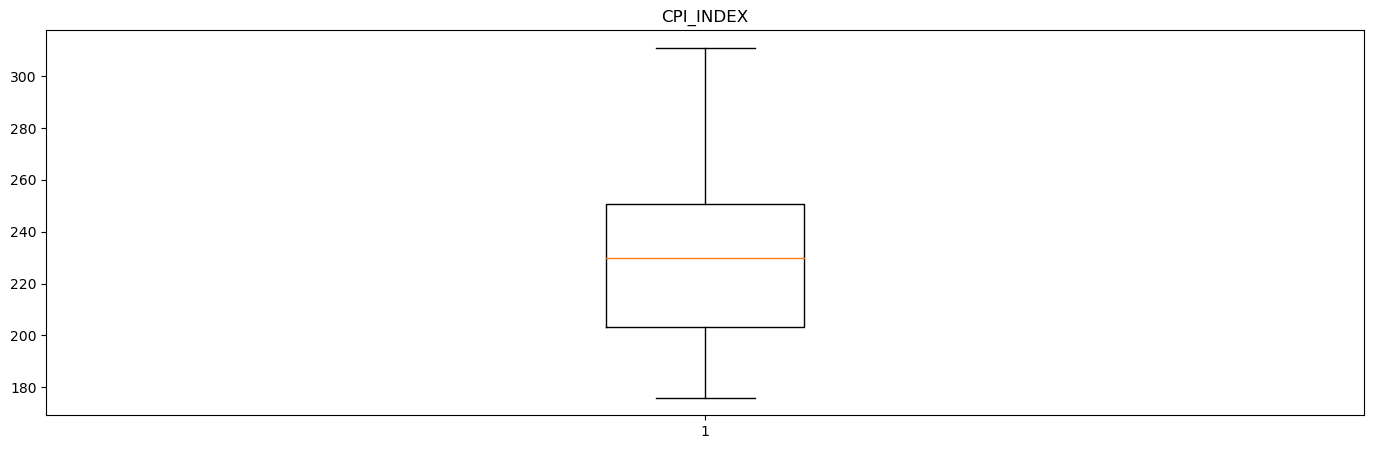

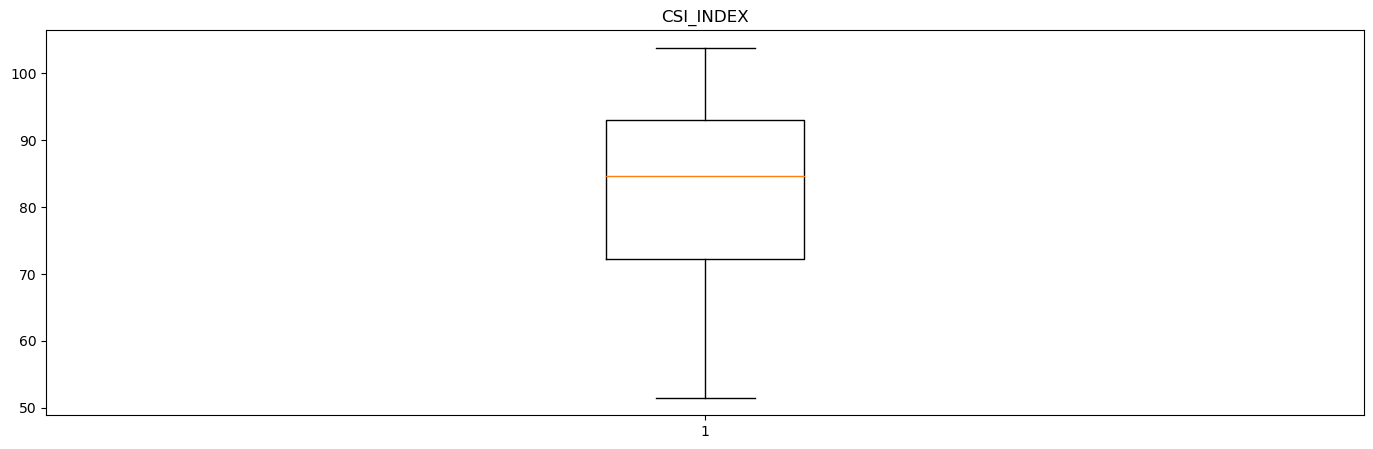

In [1099]:
#box flot
for columns in df.columns : 
    plt.figure(figsize=(17,5))
    plt.boxplot(df[columns])
    plt.title(columns.upper())
    plt.show()

In [1100]:
def check_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[col] > Q3 + 1.5 * IQR) | (df[col] < Q1 - 1.5 * (IQR))]

In [1101]:
# for column in df.columns:
print(df['eci_index'])
print(check_outliers(df, 'eci_index'))
print(len(check_outliers(df, 'eci_index')))


DATE
2001-01-01     87.6
2001-04-01     88.4
2001-07-01     89.2
2001-10-01     90.0
2002-01-01     90.7
              ...  
2023-01-01    157.1
2023-04-01    158.7
2023-07-01    160.4
2023-10-01    162.1
2024-01-01    163.9
Name: eci_index, Length: 93, dtype: float64
Empty DataFrame
Columns: [eci_index, gpd_index, oil_price, pce_index, ppi_index, wg_index, cpi_index, csi_index]
Index: []
0


In [1102]:
# for column in df.columns:
print(df['wg_index'])
print(check_outliers(df, 'wg_index'))
print(len(check_outliers(df, 'wg_index')))


DATE
2001-01-01    5.266667
2001-04-01    5.200000
2001-07-01    5.033333
2001-10-01    4.966667
2002-01-01    4.566667
                ...   
2023-01-01    6.433333
2023-04-01    5.633333
2023-07-01    5.233333
2023-10-01    5.233333
2024-01-01    4.766667
Name: wg_index, Length: 93, dtype: float64
            eci_index  gpd_index   oil_price  pce_index   ppi_index  wg_index  \
DATE                                                                            
2022-01-01      149.6      140.1   83.277619    16888.6  253.042333  5.966667   
2022-04-01      151.7      147.5  101.985238    17310.5  272.937333  6.733333   
2022-07-01      153.5      146.4  101.918095    17556.4  269.906000  6.366667   
2022-10-01      155.3      142.7   87.286667    17915.1  262.038333  6.100000   
2023-01-01      157.1      141.3   78.251364    18229.6  258.652667  6.433333   
2023-04-01      158.7      140.3   79.126500    18363.8  254.812667  5.633333   

             cpi_index  csi_index  
DATE          

In [1103]:
# for column in df.columns:
print(df['ppi_index'])
print(check_outliers(df, 'ppi_index'))
print(len(check_outliers(df, 'ppi_index')))

DATE
2001-01-01    137.766667
2001-04-01    136.233333
2001-07-01    133.366667
2001-10-01    129.400000
2002-01-01    128.900000
                 ...    
2023-01-01    258.652667
2023-04-01    254.812667
2023-07-01    256.816333
2023-10-01    252.638000
2024-01-01    253.778667
Name: ppi_index, Length: 93, dtype: float64
            eci_index  gpd_index   oil_price  pce_index   ppi_index  wg_index  \
DATE                                                                            
2022-04-01      151.7      147.5  101.985238    17310.5  272.937333  6.733333   
2022-07-01      153.5      146.4  101.918095    17556.4  269.906000  6.366667   
2022-10-01      155.3      142.7   87.286667    17915.1  262.038333  6.100000   
2023-01-01      157.1      141.3   78.251364    18229.6  258.652667  6.433333   
2023-07-01      160.4      139.4   75.766667    18595.4  256.816333  5.233333   

             cpi_index  csi_index  
DATE                               
2022-04-01  291.706333       65.2  


In [1104]:
df

,eci_index,gpd_index,oil_price,pce_index,ppi_index,wg_index,cpi_index,csi_index
DATE,,,,,,,,
2001-01-01,87.6,100.5,29.482174,6987.4,137.766667,5.266667,175.900000,94.7
2001-04-01,88.4,97.8,27.453810,7004.2,136.233333,5.200000,177.133333,88.4
2001-07-01,89.2,96.1,26.435909,7082.3,133.366667,5.033333,177.633333,92.4
2001-10-01,90.0,93.7,22.210435,7212.9,129.400000,4.966667,177.500000,82.7
2002-01-01,90.7,91.6,19.607391,7184.6,128.900000,4.566667,178.066667,93.0
...,...,...,...,...,...,...,...,...
2023-01-01,157.1,141.3,78.251364,18229.6,258.652667,6.433333,301.203000,64.9
2023-04-01,158.7,140.3,79.126500,18363.8,254.812667,5.633333,303.466667,63.7
2023-07-01,160.4,139.4,75.766667,18595.4,256.816333,5.233333,306.034333,71.5


In [1108]:
cpi_and_csi = df[['cpi_index', 'csi_index']]

In [1109]:
#resample to yearly
cpi_and_csi_yearly = cpi_and_csi.resample('Y').mean()

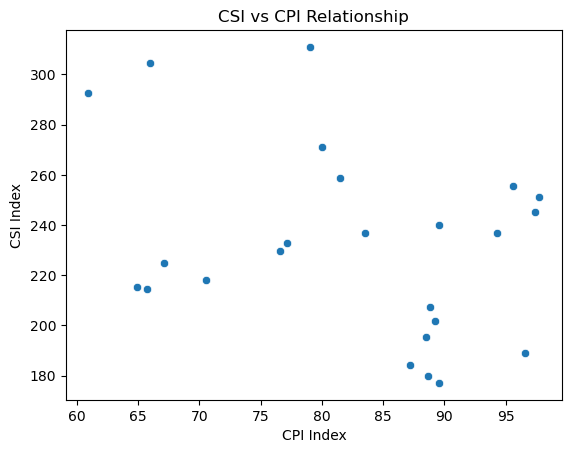

In [1112]:
sns.scatterplot( data=cpi_and_csi_yearly, x='csi_index', y='cpi_index')
plt.title('CSI vs CPI Relationship')
plt.xlabel('CPI Index')
plt.ylabel('CSI Index')
plt.show()

In [1113]:
cpi_and_csi_yearly

,cpi_index,csi_index
DATE,,
2001-12-31,177.041667,89.550
2002-12-31,179.866667,88.675
2003-12-31,184.000000,87.225
2004-12-31,188.908333,96.600
2005-12-31,195.266667,88.475
2006-12-31,201.558333,89.225
2007-12-31,207.344167,88.825
2008-12-31,215.254250,64.950
2009-12-31,214.564667,65.725


In [1114]:
cpi_and_csi_yearly['shifted'] = cpi_and_csi_yearly['cpi_index'].shift(1)
cpi_and_csi_yearly

,cpi_index,csi_index,shifted
DATE,,,
2001-12-31,177.041667,89.550,NaN
2002-12-31,179.866667,88.675,177.041667
2003-12-31,184.000000,87.225,179.866667
2004-12-31,188.908333,96.600,184.000000
2005-12-31,195.266667,88.475,188.908333
2006-12-31,201.558333,89.225,195.266667
2007-12-31,207.344167,88.825,201.558333
2008-12-31,215.254250,64.950,207.344167
2009-12-31,214.564667,65.725,215.254250


In [1115]:
cpi_and_csi_yearly['inflation'] = (cpi_and_csi_yearly['cpi_index'] - cpi_and_csi_yearly['shifted']) / cpi_and_csi_yearly['shifted'] * 100
cpi_and_csi_yearly

,cpi_index,csi_index,shifted,inflation
DATE,,,,
2001-12-31,177.041667,89.550,NaN,NaN
2002-12-31,179.866667,88.675,177.041667,1.595670
2003-12-31,184.000000,87.225,179.866667,2.297999
2004-12-31,188.908333,96.600,184.000000,2.667572
2005-12-31,195.266667,88.475,188.908333,3.365830
2006-12-31,201.558333,89.225,195.266667,3.222089
2007-12-31,207.344167,88.825,201.558333,2.870550
2008-12-31,215.254250,64.950,207.344167,3.814953
2009-12-31,214.564667,65.725,215.254250,-0.320358


In [1116]:
cpi_and_csi_yearly.dropna(inplace=True)
cpi_and_csi_yearly

,cpi_index,csi_index,shifted,inflation
DATE,,,,
2002-12-31,179.866667,88.675,177.041667,1.595670
2003-12-31,184.000000,87.225,179.866667,2.297999
2004-12-31,188.908333,96.600,184.000000,2.667572
2005-12-31,195.266667,88.475,188.908333,3.365830
2006-12-31,201.558333,89.225,195.266667,3.222089
2007-12-31,207.344167,88.825,201.558333,2.870550
2008-12-31,215.254250,64.950,207.344167,3.814953
2009-12-31,214.564667,65.725,215.254250,-0.320358
2010-12-31,218.076167,70.525,214.564667,1.636570


In [1117]:
cpi_and_csi_yearly[['csi_index', 'inflation']].corr()


,csi_index,inflation
csi_index,1.000000,-0.371017
inflation,-0.371017,1.000000


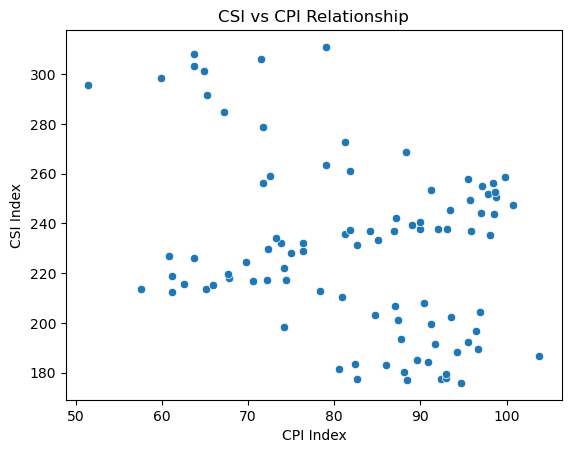

In [1118]:
sns.scatterplot( data=cpi_and_csi, x='csi_index', y='cpi_index')
plt.title('CSI vs CPI Relationship')
plt.xlabel('CPI Index')
plt.ylabel('CSI Index')
plt.show()

In [1119]:
cpi_and_csi.corr()

,cpi_index,csi_index
cpi_index,1.00000,-0.31278
csi_index,-0.31278,1.00000


<Axes: xlabel='DATE'>

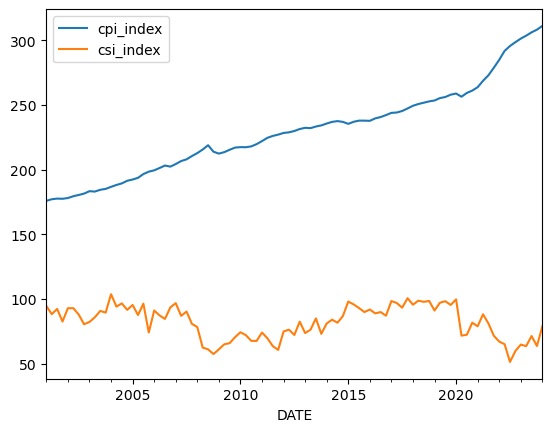

In [1120]:
cpi_and_csi.plot()

/Users/anbschool0026/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


[]

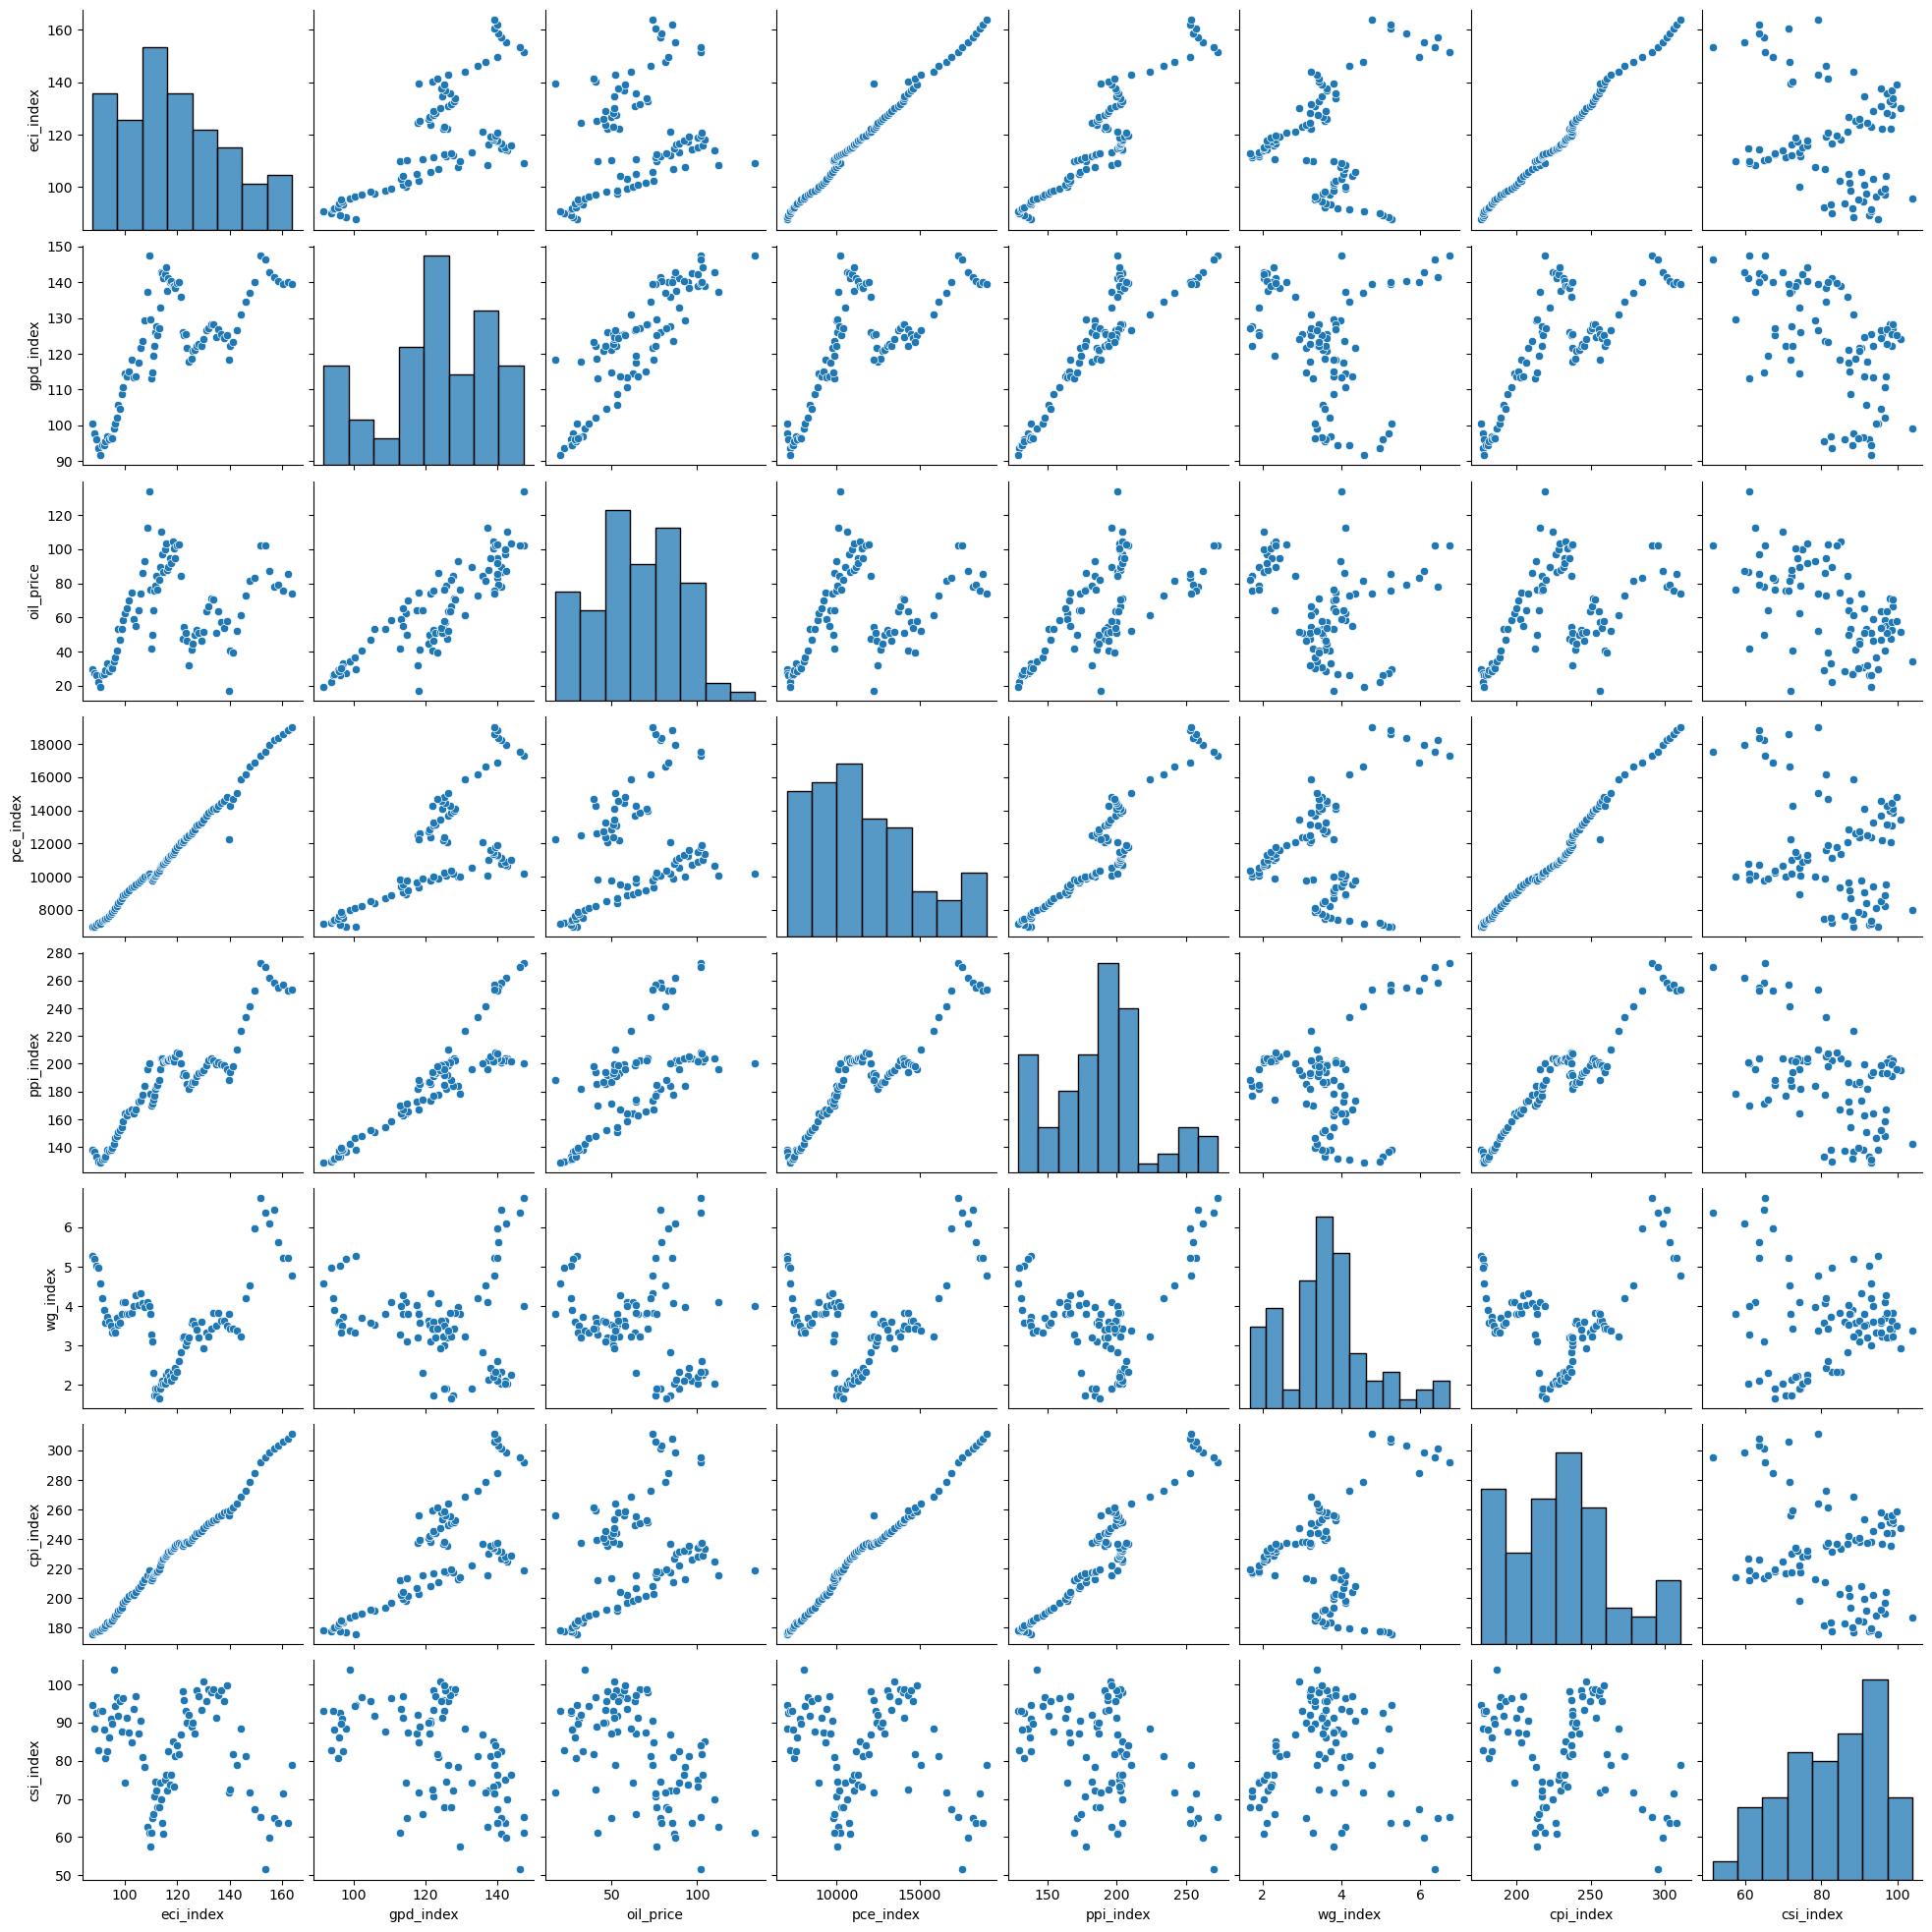

In [1121]:
sns.pairplot(df)

plt.plot()

In [1122]:
df.corr()

,eci_index,gpd_index,oil_price,pce_index,ppi_index,wg_index,cpi_index,csi_index
eci_index,1.000000,0.697173,0.326078,0.992984,0.916578,0.277803,0.994817,-0.267248
gpd_index,0.697173,1.000000,0.867337,0.693572,0.889516,-0.112798,0.749638,-0.524081
oil_price,0.326078,0.867337,1.000000,0.343119,0.641075,-0.186120,0.400213,-0.550574
pce_index,0.992984,0.693572,0.343119,1.000000,0.924183,0.332308,0.992509,-0.245830
ppi_index,0.916578,0.889516,0.641075,0.924183,1.000000,0.219919,0.948008,-0.468496
wg_index,0.277803,-0.112798,-0.186120,0.332308,0.219919,1.000000,0.275584,-0.061657
cpi_index,0.994817,0.749638,0.400213,0.992509,0.948008,0.275584,1.000000,-0.312780
csi_index,-0.267248,-0.524081,-0.550574,-0.245830,-0.468496,-0.061657,-0.312780,1.000000


In [1126]:
highly_corr = df[['eci_index', 'gpd_index', 'ppi_index', 'cpi_index']] # group them

In [1127]:
highly_corr.corr()

,eci_index,gpd_index,ppi_index,cpi_index
eci_index,1.000000,0.697173,0.916578,0.994817
gpd_index,0.697173,1.000000,0.889516,0.749638
ppi_index,0.916578,0.889516,1.000000,0.948008
cpi_index,0.994817,0.749638,0.948008,1.000000


<Axes: xlabel='DATE'>

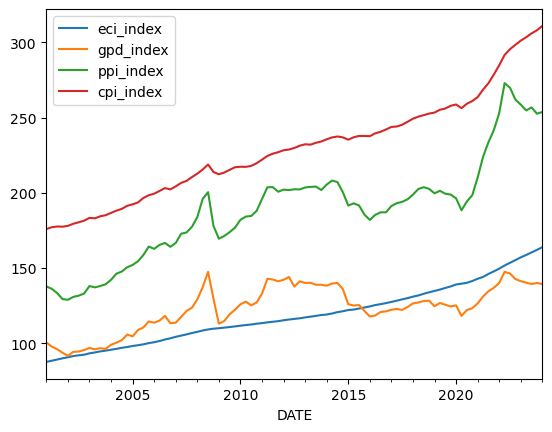

In [1128]:
highly_corr.plot()

In [1130]:
from scipy.stats import pearsonr, spearmanr
for i in highly_corr.columns.drop('cpi_index'):
    corr, _ = pearsonr(highly_corr[i], highly_corr['cpi_index'])
    print(f"Pearson correlation between {i} and cpi_index: {corr:.4f}")

Pearson correlation between eci_index and cpi_index: 0.9948
Pearson correlation between gpd_index and cpi_index: 0.7496
Pearson correlation between ppi_index and cpi_index: 0.9480


In [1131]:
highly_corr

,eci_index,gpd_index,ppi_index,cpi_index
DATE,,,,
2001-01-01,87.6,100.5,137.766667,175.900000
2001-04-01,88.4,97.8,136.233333,177.133333
2001-07-01,89.2,96.1,133.366667,177.633333
2001-10-01,90.0,93.7,129.400000,177.500000
2002-01-01,90.7,91.6,128.900000,178.066667
...,...,...,...,...
2023-01-01,157.1,141.3,258.652667,301.203000
2023-04-01,158.7,140.3,254.812667,303.466667
2023-07-01,160.4,139.4,256.816333,306.034333


<Axes: xlabel='DATE'>

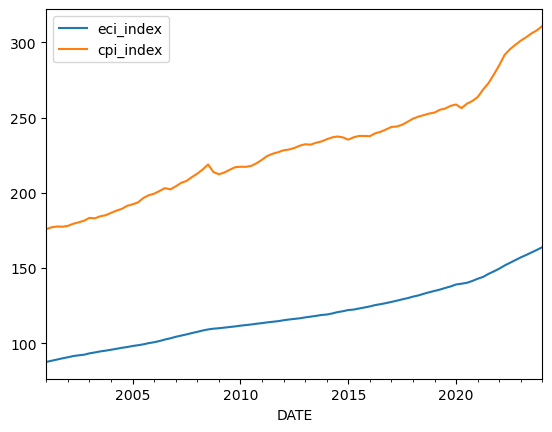

In [1132]:
highly_corr[['eci_index', 'cpi_index']].plot()

<Axes: xlabel='DATE'>

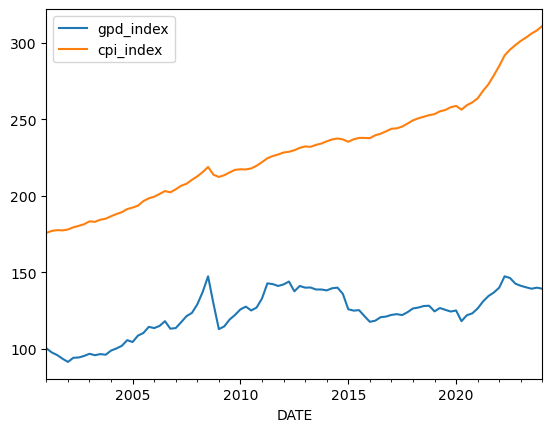

In [1133]:
highly_corr[['gpd_index', 'cpi_index']].plot()

<Axes: xlabel='DATE'>

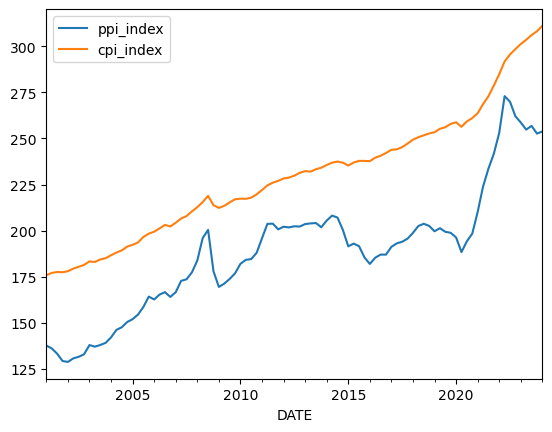

In [1134]:
highly_corr[['ppi_index', 'cpi_index']].plot()

In [1138]:
df_yearly = df.resample('Y').mean()

In [1139]:
from sklearn.preprocessing import MinMaxScaler
mm = MinMaxScaler()

df_yearly_1 = df_yearly.copy()

for column in df_yearly_1.columns:
    df_yearly_1[column] = mm.fit_transform(df_yearly_1[[column]])

/Users/anbschool0026/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


[]

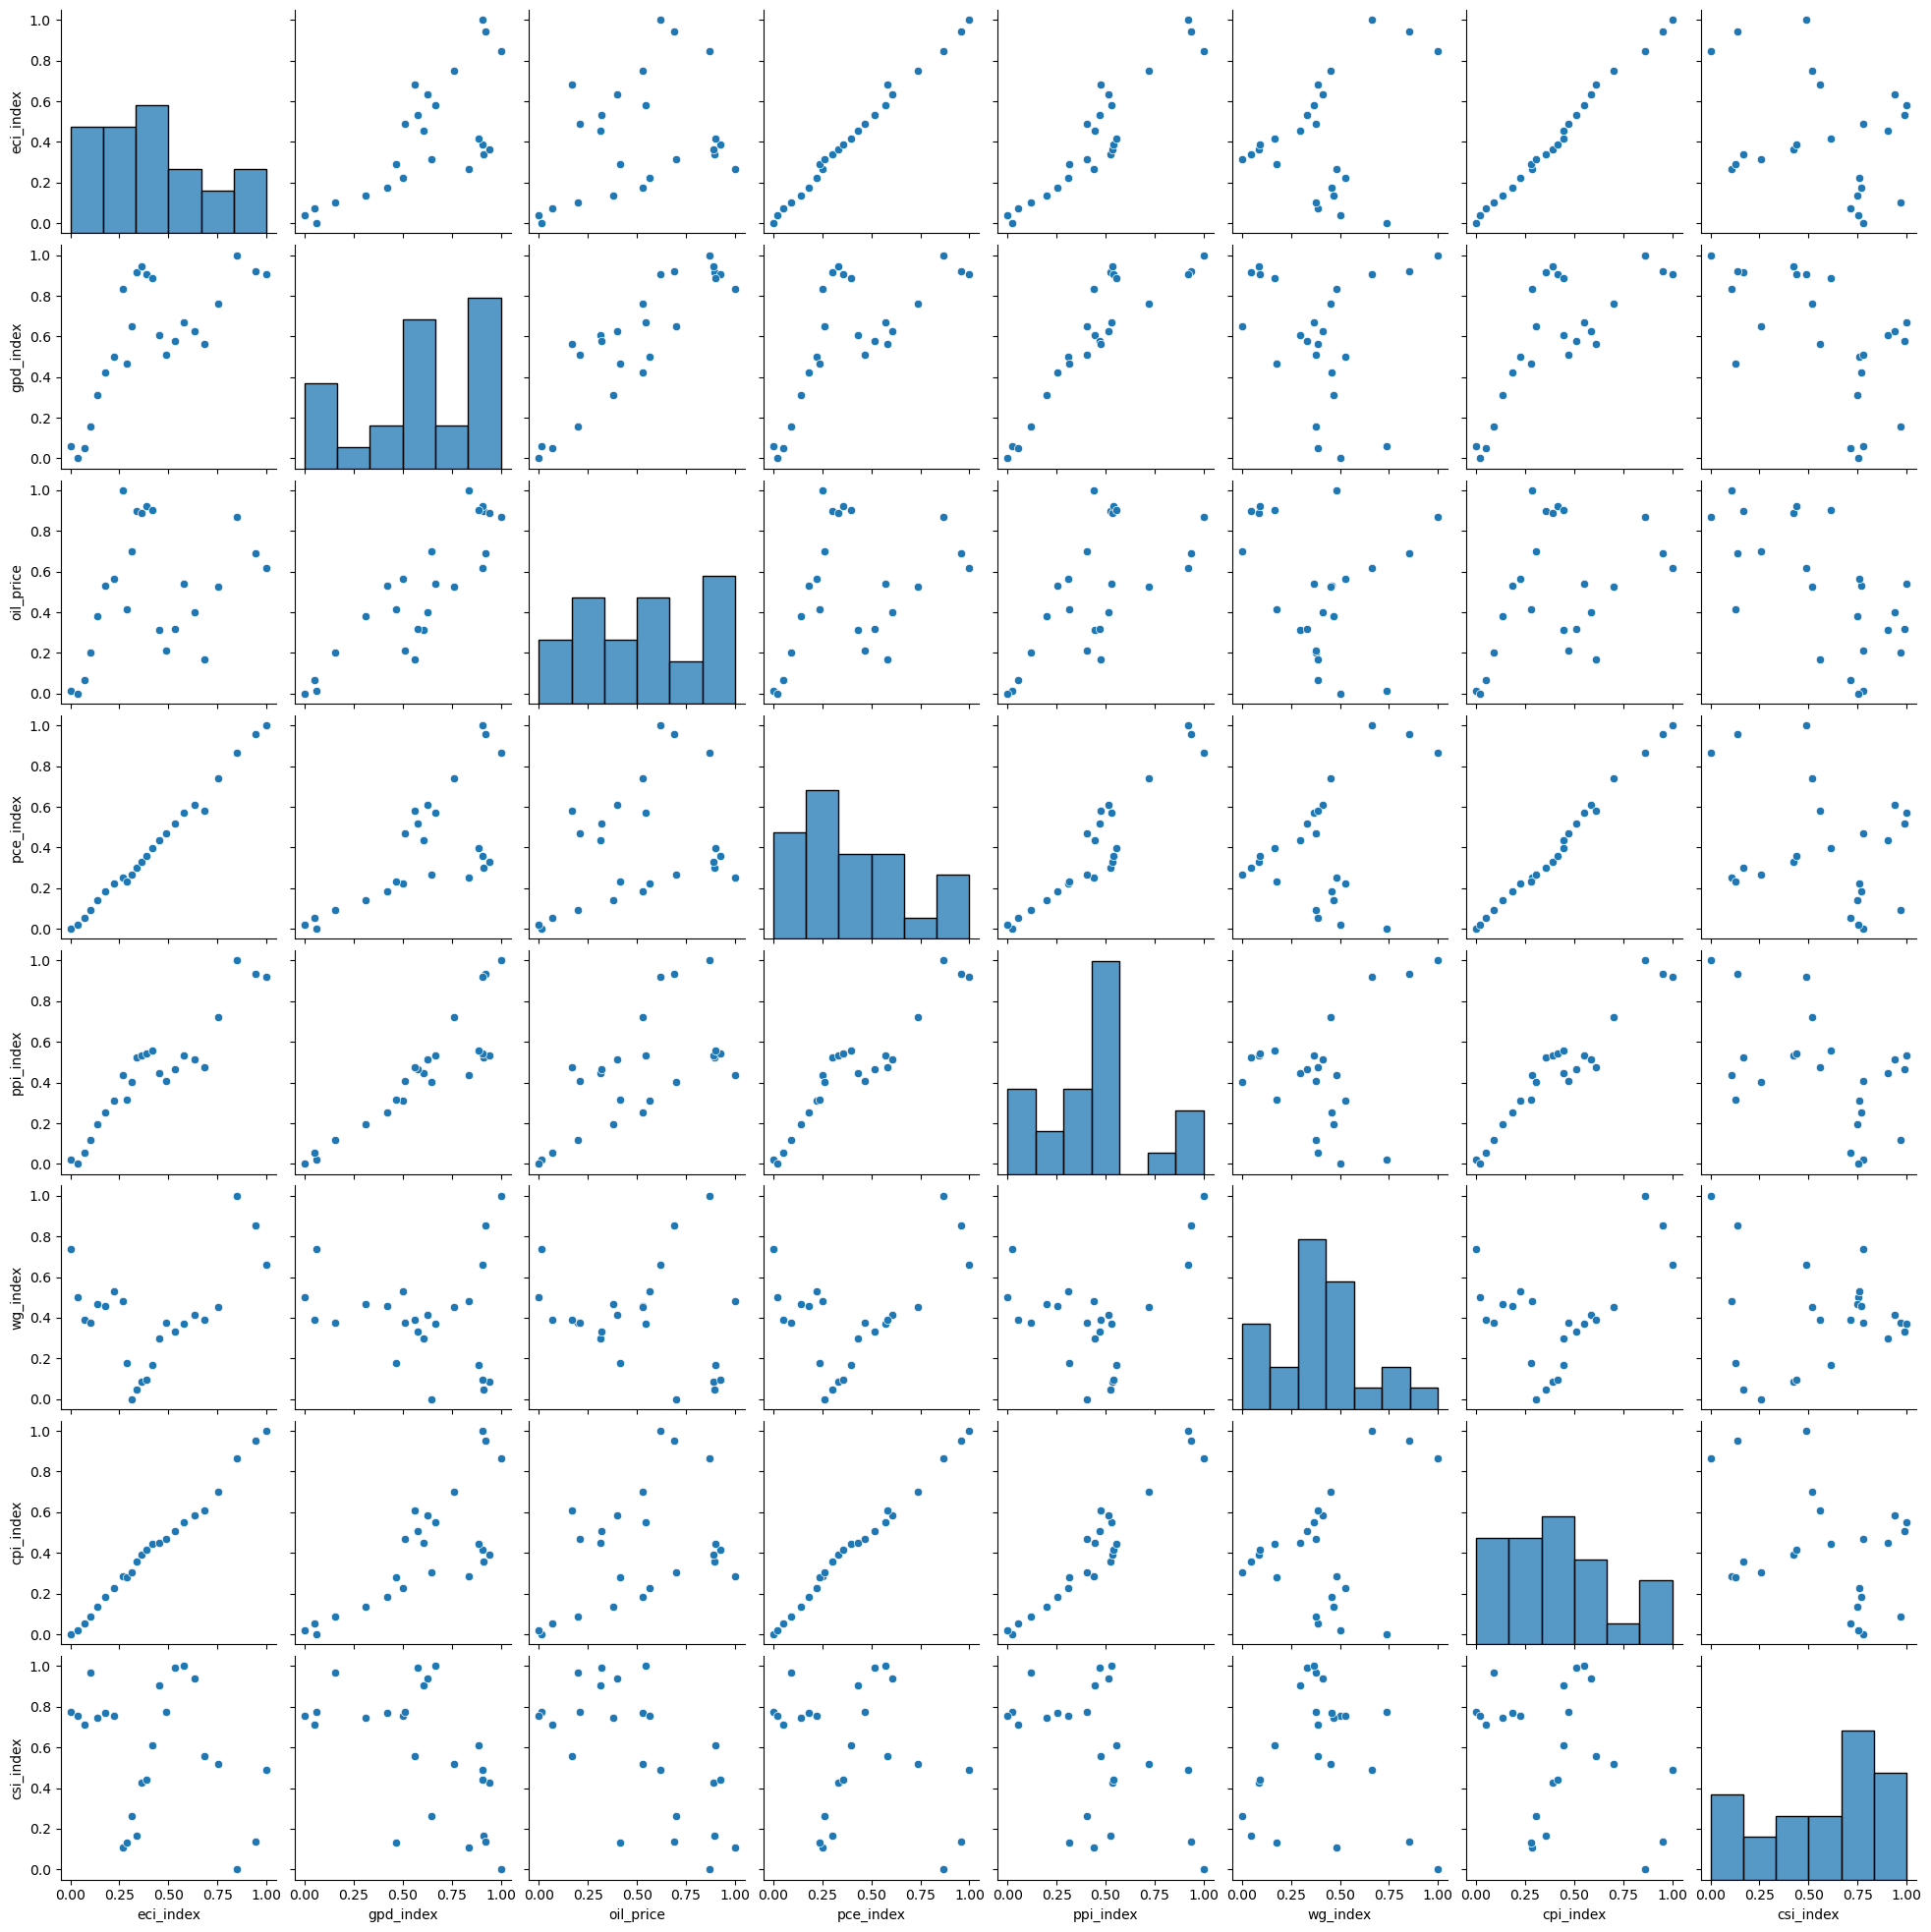

In [1140]:
sns.pairplot(df_yearly_1)

plt.plot()

In [1141]:
df_yearly_1.corr()

,eci_index,gpd_index,oil_price,pce_index,ppi_index,wg_index,cpi_index,csi_index
eci_index,1.000000,0.713999,0.340671,0.996106,0.930329,0.332651,0.995874,-0.283826
gpd_index,0.713999,1.000000,0.872990,0.707886,0.890010,-0.081806,0.758194,-0.564784
oil_price,0.340671,0.872990,1.000000,0.347576,0.636350,-0.185885,0.405878,-0.634973
pce_index,0.996106,0.707886,0.347576,1.000000,0.936175,0.384686,0.995377,-0.271419
ppi_index,0.930329,0.890010,0.636350,0.936175,1.000000,0.265463,0.955609,-0.494668
wg_index,0.332651,-0.081806,-0.185885,0.384686,0.265463,1.000000,0.330345,-0.065252
cpi_index,0.995874,0.758194,0.405878,0.995377,0.955609,0.330345,1.000000,-0.327786
csi_index,-0.283826,-0.564784,-0.634973,-0.271419,-0.494668,-0.065252,-0.327786,1.000000


<Axes: xlabel='DATE'>

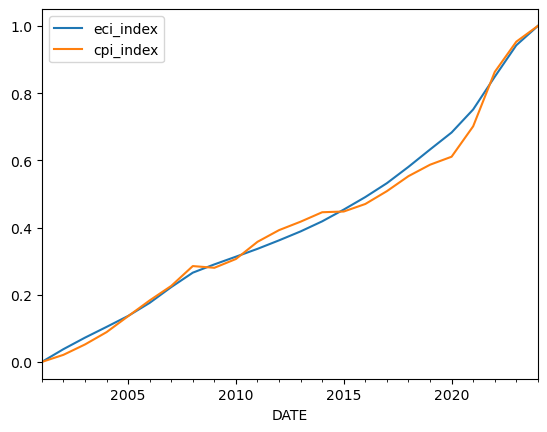

In [1144]:
df_yearly_1[['eci_index', 'cpi_index']].plot()

<Axes: xlabel='DATE'>

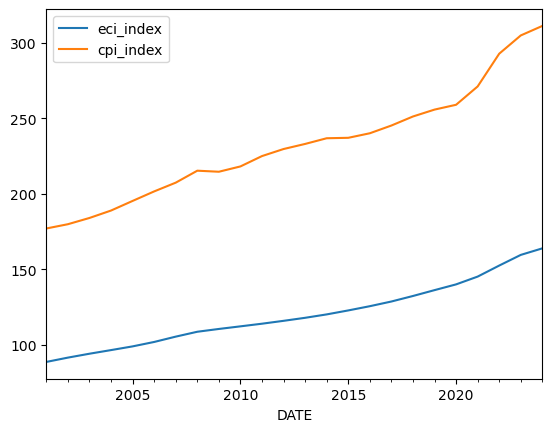

In [1143]:
df_yearly[['eci_index', 'cpi_index']].plot()

<Axes: xlabel='DATE'>

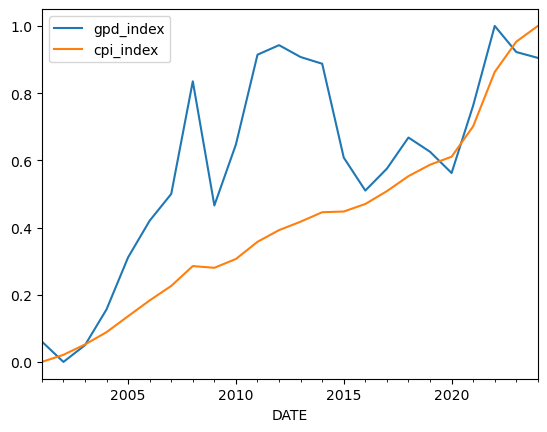

In [1145]:
df_yearly_1[['gpd_index', 'cpi_index']].plot()

<Axes: xlabel='DATE'>

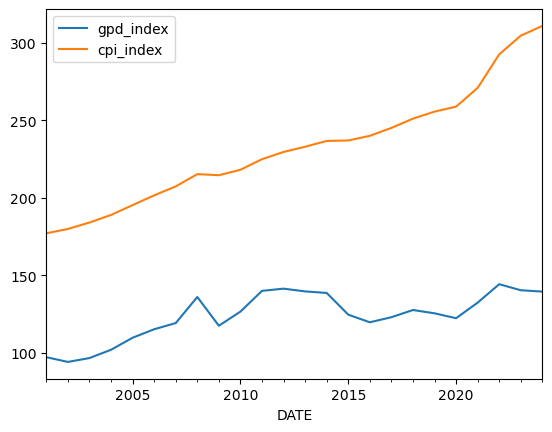

In [1146]:
df_yearly[['gpd_index', 'cpi_index']].plot()

<Axes: xlabel='DATE'>

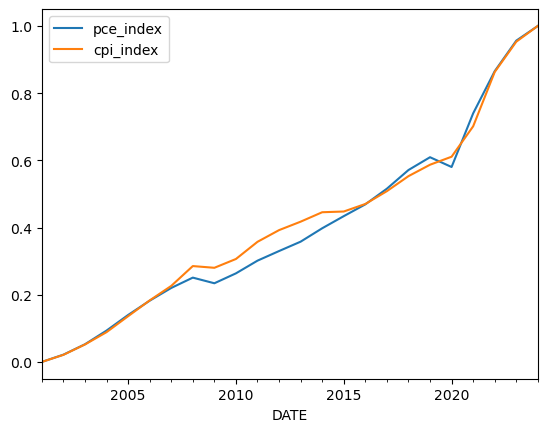

In [1148]:
df_yearly_1[['pce_index', 'cpi_index']].plot()

<Axes: xlabel='DATE'>

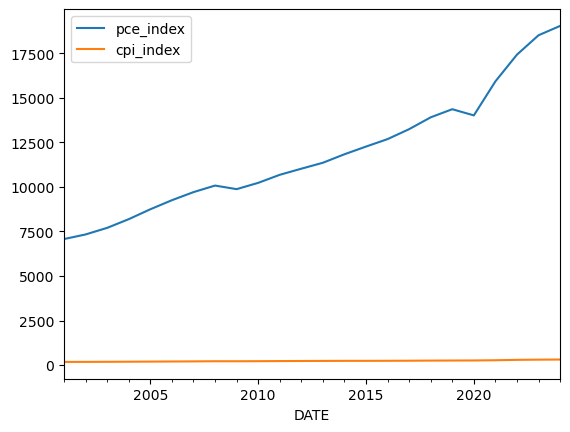

In [1149]:
df_yearly[['pce_index', 'cpi_index']].plot()

<Axes: xlabel='DATE'>

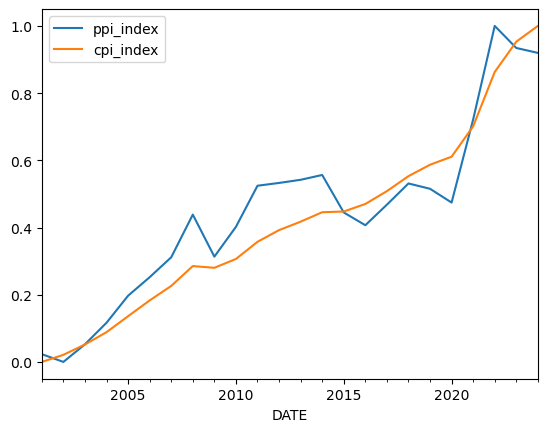

In [1150]:
df_yearly_1[['ppi_index', 'cpi_index']].plot()

<Axes: xlabel='DATE'>

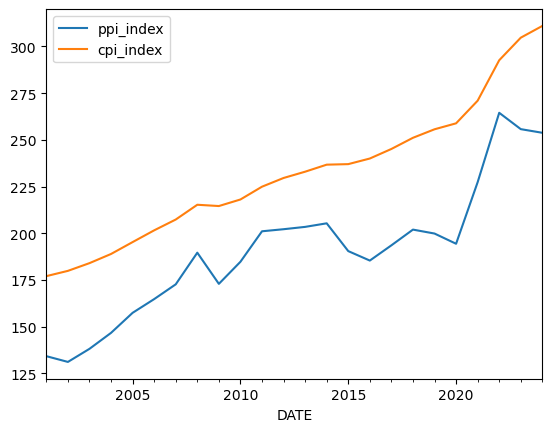

In [1151]:
df_yearly[['ppi_index', 'cpi_index']].plot()